Cargado generated-nets/hist2d_er_avgOverSeeds_norm.npy con forma (20, 35)
Cargado generated-nets/hist2d_ba_avgOverSeeds_norm.npy con forma (20, 35)
Cargado generated-nets/hist2d_conf_avgOverSeeds_norm.npy con forma (20, 35)
Cargado generated-nets/hist2d_s1h2_avgOverSeeds_norm.npy con forma (20, 35)


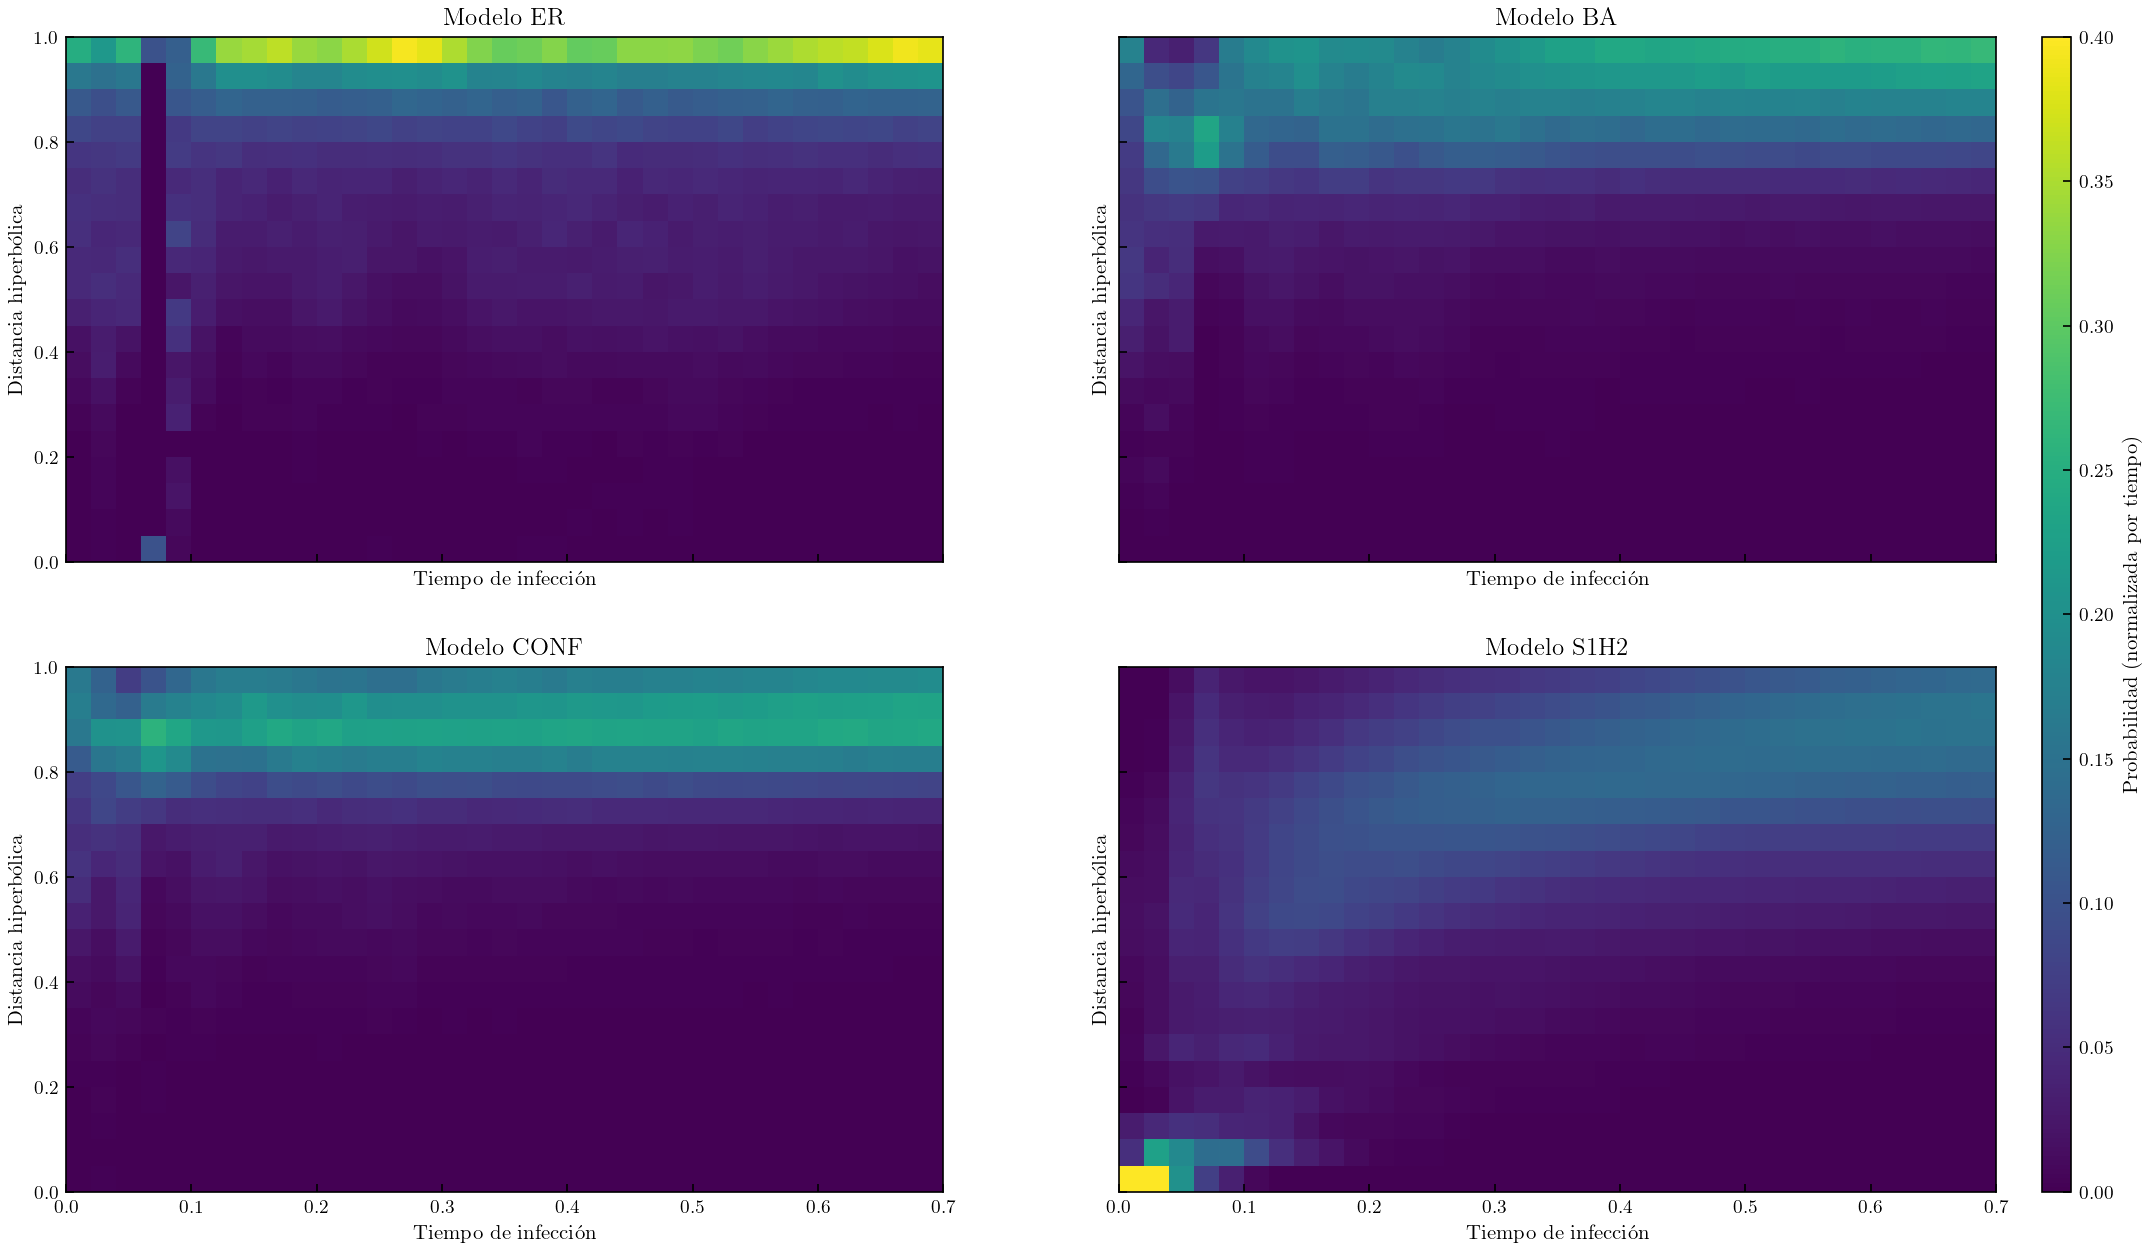

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pipeline.init as init

init.configure_matplotlib()

# =============================================================================
# Configuración
# =============================================================================
MODELS = ["er", "ba", "conf", "s1h2"]
DIST_MIN, DIST_MAX = 0.0, 1.0
TIME_MIN, TIME_MAX = 0.0, 0.7
NUM_DIST_BINS = 20
NUM_TIME_BINS = 35

dist_bins = np.linspace(DIST_MIN, DIST_MAX, NUM_DIST_BINS + 1)
time_bins = np.linspace(TIME_MIN, TIME_MAX, NUM_TIME_BINS + 1)

# =============================================================================
# Función para dibujar un subplot con mapa de calor
# =============================================================================
def draw_heatmap(ax, H_norm, dist_bins, time_bins, title, vmin=0, vmax=0.4):
    dist_centers = (dist_bins[:-1] + dist_bins[1:]) / 2
    time_centers = (time_bins[:-1] + time_bins[1:]) / 2
    im = ax.pcolormesh(time_centers, dist_centers, H_norm,
                       shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_xlabel("Tiempo de infección")
    ax.set_ylabel("Distancia hiperbólica")
    ax.set_title(title)
    return im

# =============================================================================
# Cargar todos los arrays .npy
# =============================================================================
data = {}
for model in MODELS:
    npy_file = f"generated-nets/hist2d_{model}_avgOverSeeds_norm.npy"
    if not os.path.exists(npy_file):
        print(f"Archivo no encontrado: {npy_file} – omitiendo {model}")
        data[model] = None
    else:
        H_norm = np.load(npy_file)
        print(f"Cargado {npy_file} con forma {H_norm.shape}")
        data[model] = H_norm

# Verificar que todos los modelos tengan datos
if any(v is None for v in data.values()):
    print("Faltan datos para algún modelo. Saliendo.")
    exit(1)

# =============================================================================
# Crear figura con 2x2 subplots
# =============================================================================
fig, axes = plt.subplots(2, 2, dpi=150, figsize=(20, 10), sharex=True, sharey=True)
ax_flat = axes.flatten()

# Parámetros comunes para el colorbar
vmin, vmax = 0, 0.4

# Dibujar cada subplot
for ax, model in zip(ax_flat, MODELS):
    im = draw_heatmap(ax, data[model], dist_bins, time_bins,
                      title=f"Modelo {model.upper()}", vmin=vmin, vmax=vmax)

# Añadir una barra de color común en la parte inferior
cbar = fig.colorbar(im, ax=axes, orientation='vertical', pad=0.02, aspect=40)
cbar.set_label("Probabilidad (normalizada por tiempo)")

# plt.suptitle("Mapas de calor de distancia vs tiempo de infección\n(promedio sobre semillas)", fontsize=14)
# plt.tight_layout()
plt.savefig("heatmap_all_models.png", dpi=150)
plt.show()